In [118]:
function ε_norm_eq_subplots(datasets, CR; cols=2, main_title="")
    n_datasets = length(datasets)
    rows = ceil(Int, n_datasets / cols)
    
    fig = Figure(size=(500*cols + 100, 360*rows))  # Extra width for single colorbar
    
    # Add main title if provided
    if !isempty(main_title)
        Label(fig[0, :], main_title, fontsize=25, tellwidth=false)
    end
    
    heatmaps = []  # Store heatmap objects
    
    for (i, ds) in enumerate(datasets)
        row = ceil(Int, i / cols)
        col = ((i - 1) % cols) + 1
        
        # Get data for this dataset
        ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
        Ra = ds.attrib["Ra"]
        time = ds["time"][:]
        x = ds["xC"][4+1:end-4]
        z = ds["zC"][4+1:end-4]
        equilibrium_start = round(Int, 0.9 * size(time, 1))
        ε_eq = ε[:, :, equilibrium_start]
        ε_theory = ε_analysis(ds)[1]
        ε_norm = ε_eq ./ ε_theory
        
        # Create subplot
        ax = Axis(fig[row, col], aspect=8, 
                xlabel="x", ylabel="z", 
                title="Ra = $Ra")
        hm = heatmap!(ax, x, z, ε_norm, colorrange=CR, colormap=:viridis)
        push!(heatmaps, hm)
    end
    
    # Add single colorbar on the right side
    Colorbar(fig[:, end+1], heatmaps[1], label=L"ε/ε_{crit}")
    
    return fig
end

ε_norm_eq_subplots (generic function with 1 method)

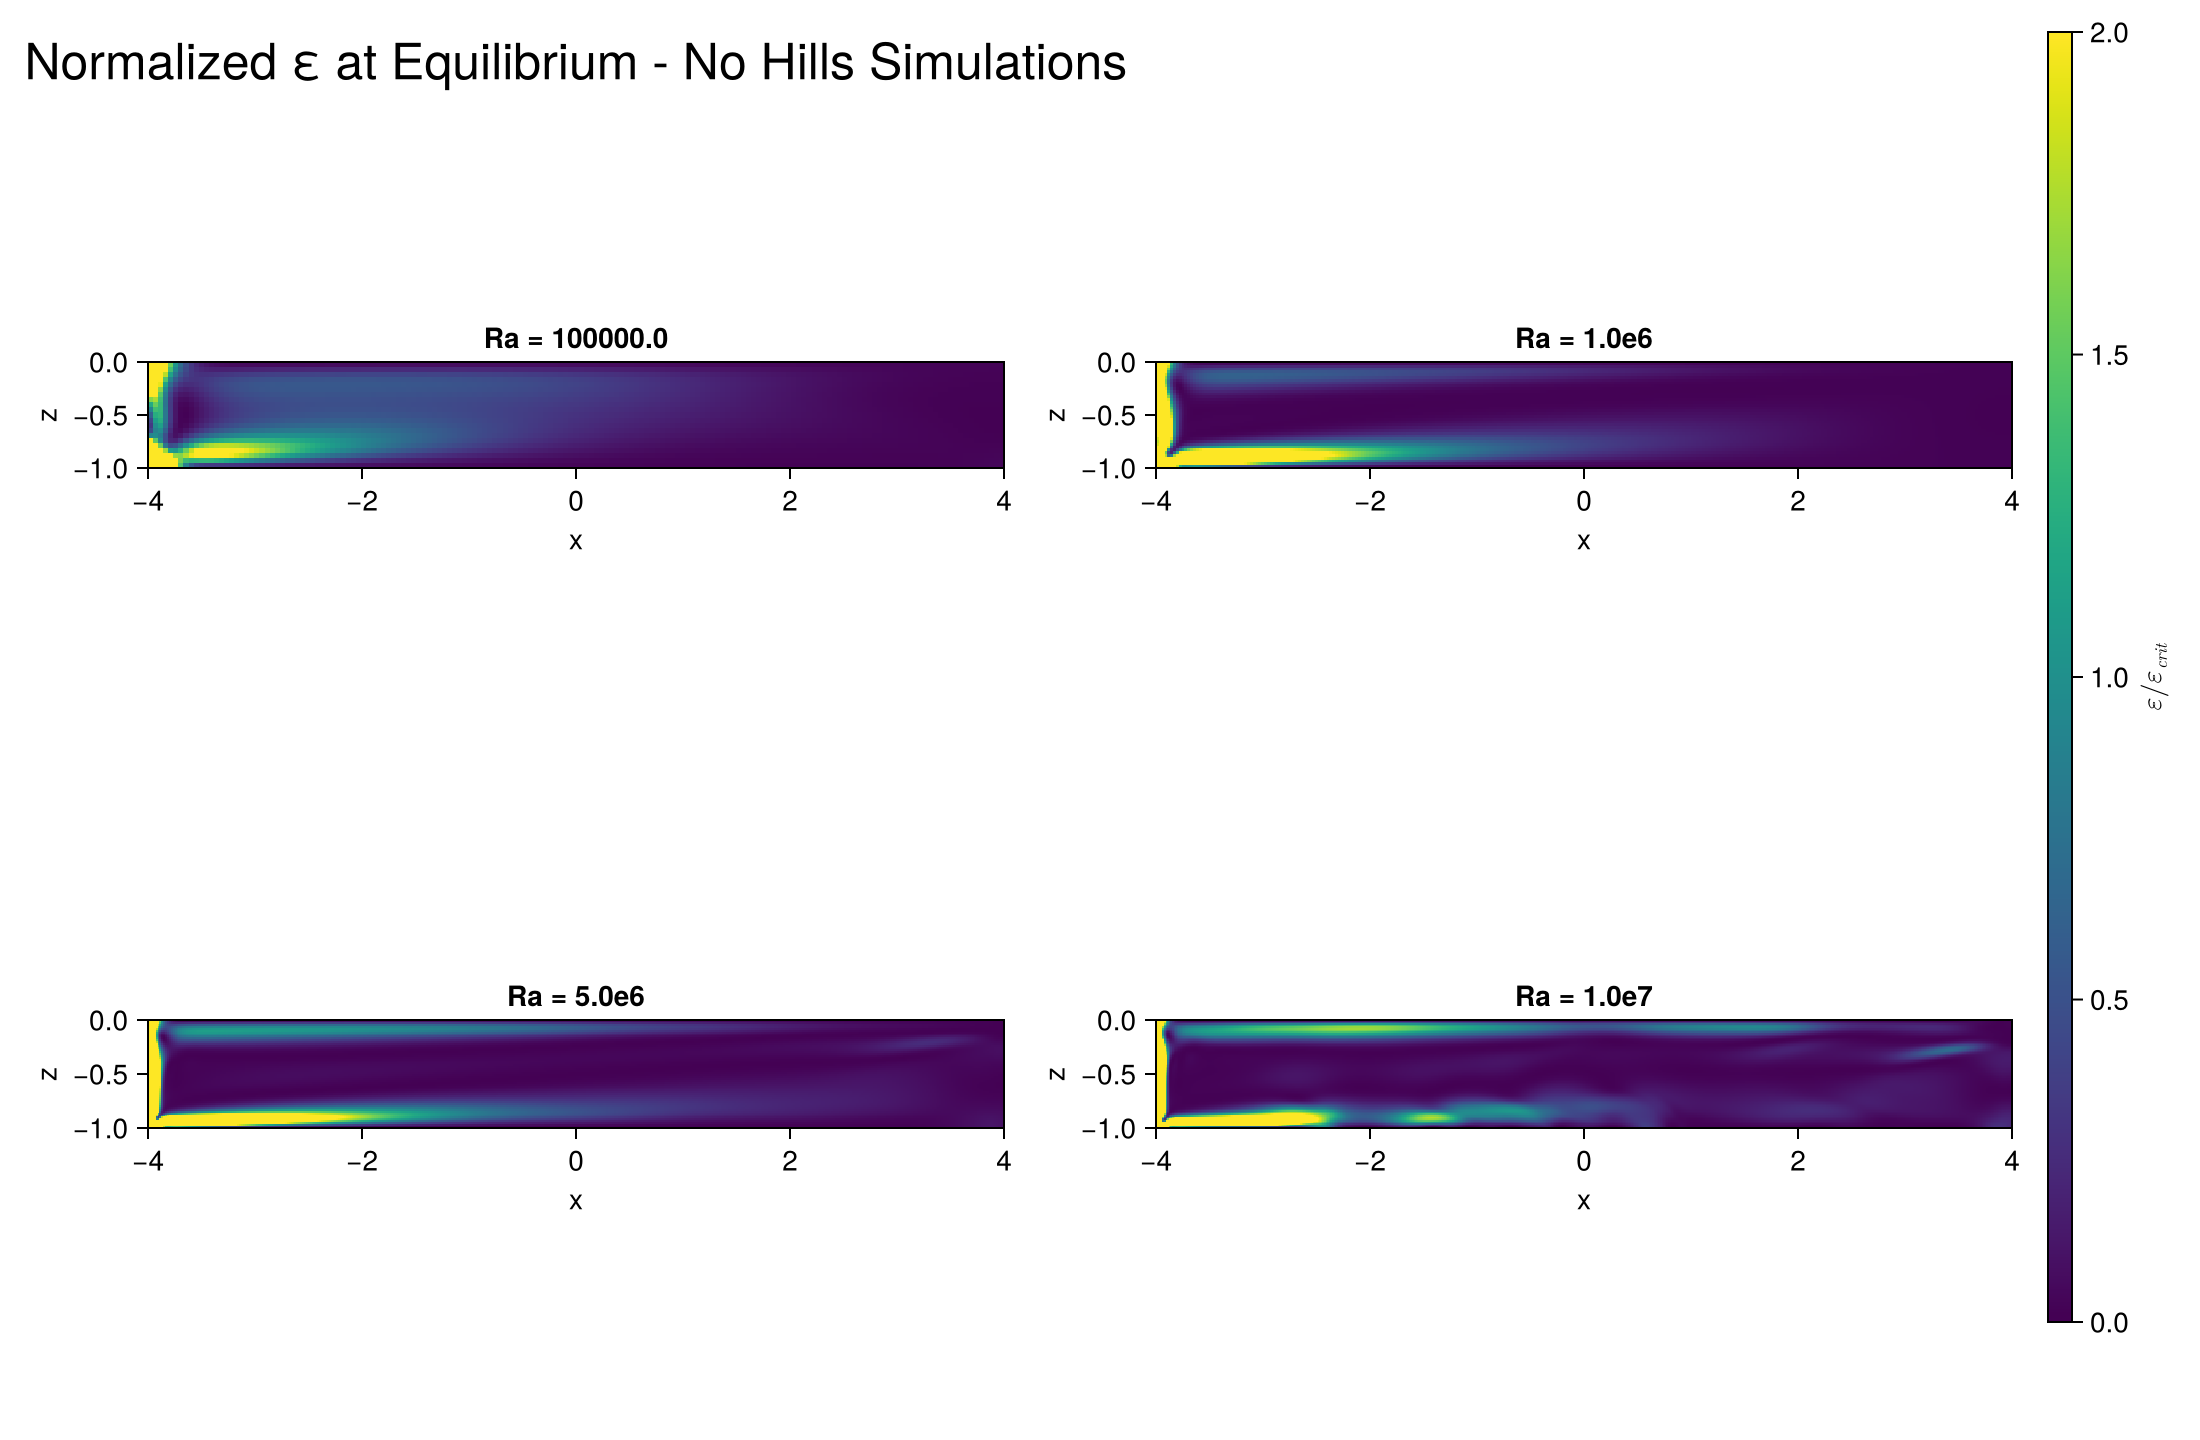

In [119]:
# Create subplots for all no-hill datasets
fig_no_hills = ε_norm_eq_subplots(list_of_datasets, (0,2), cols=2, 
        main_title="Normalized ε at Equilibrium - No Hills Simulations")
fig_no_hills

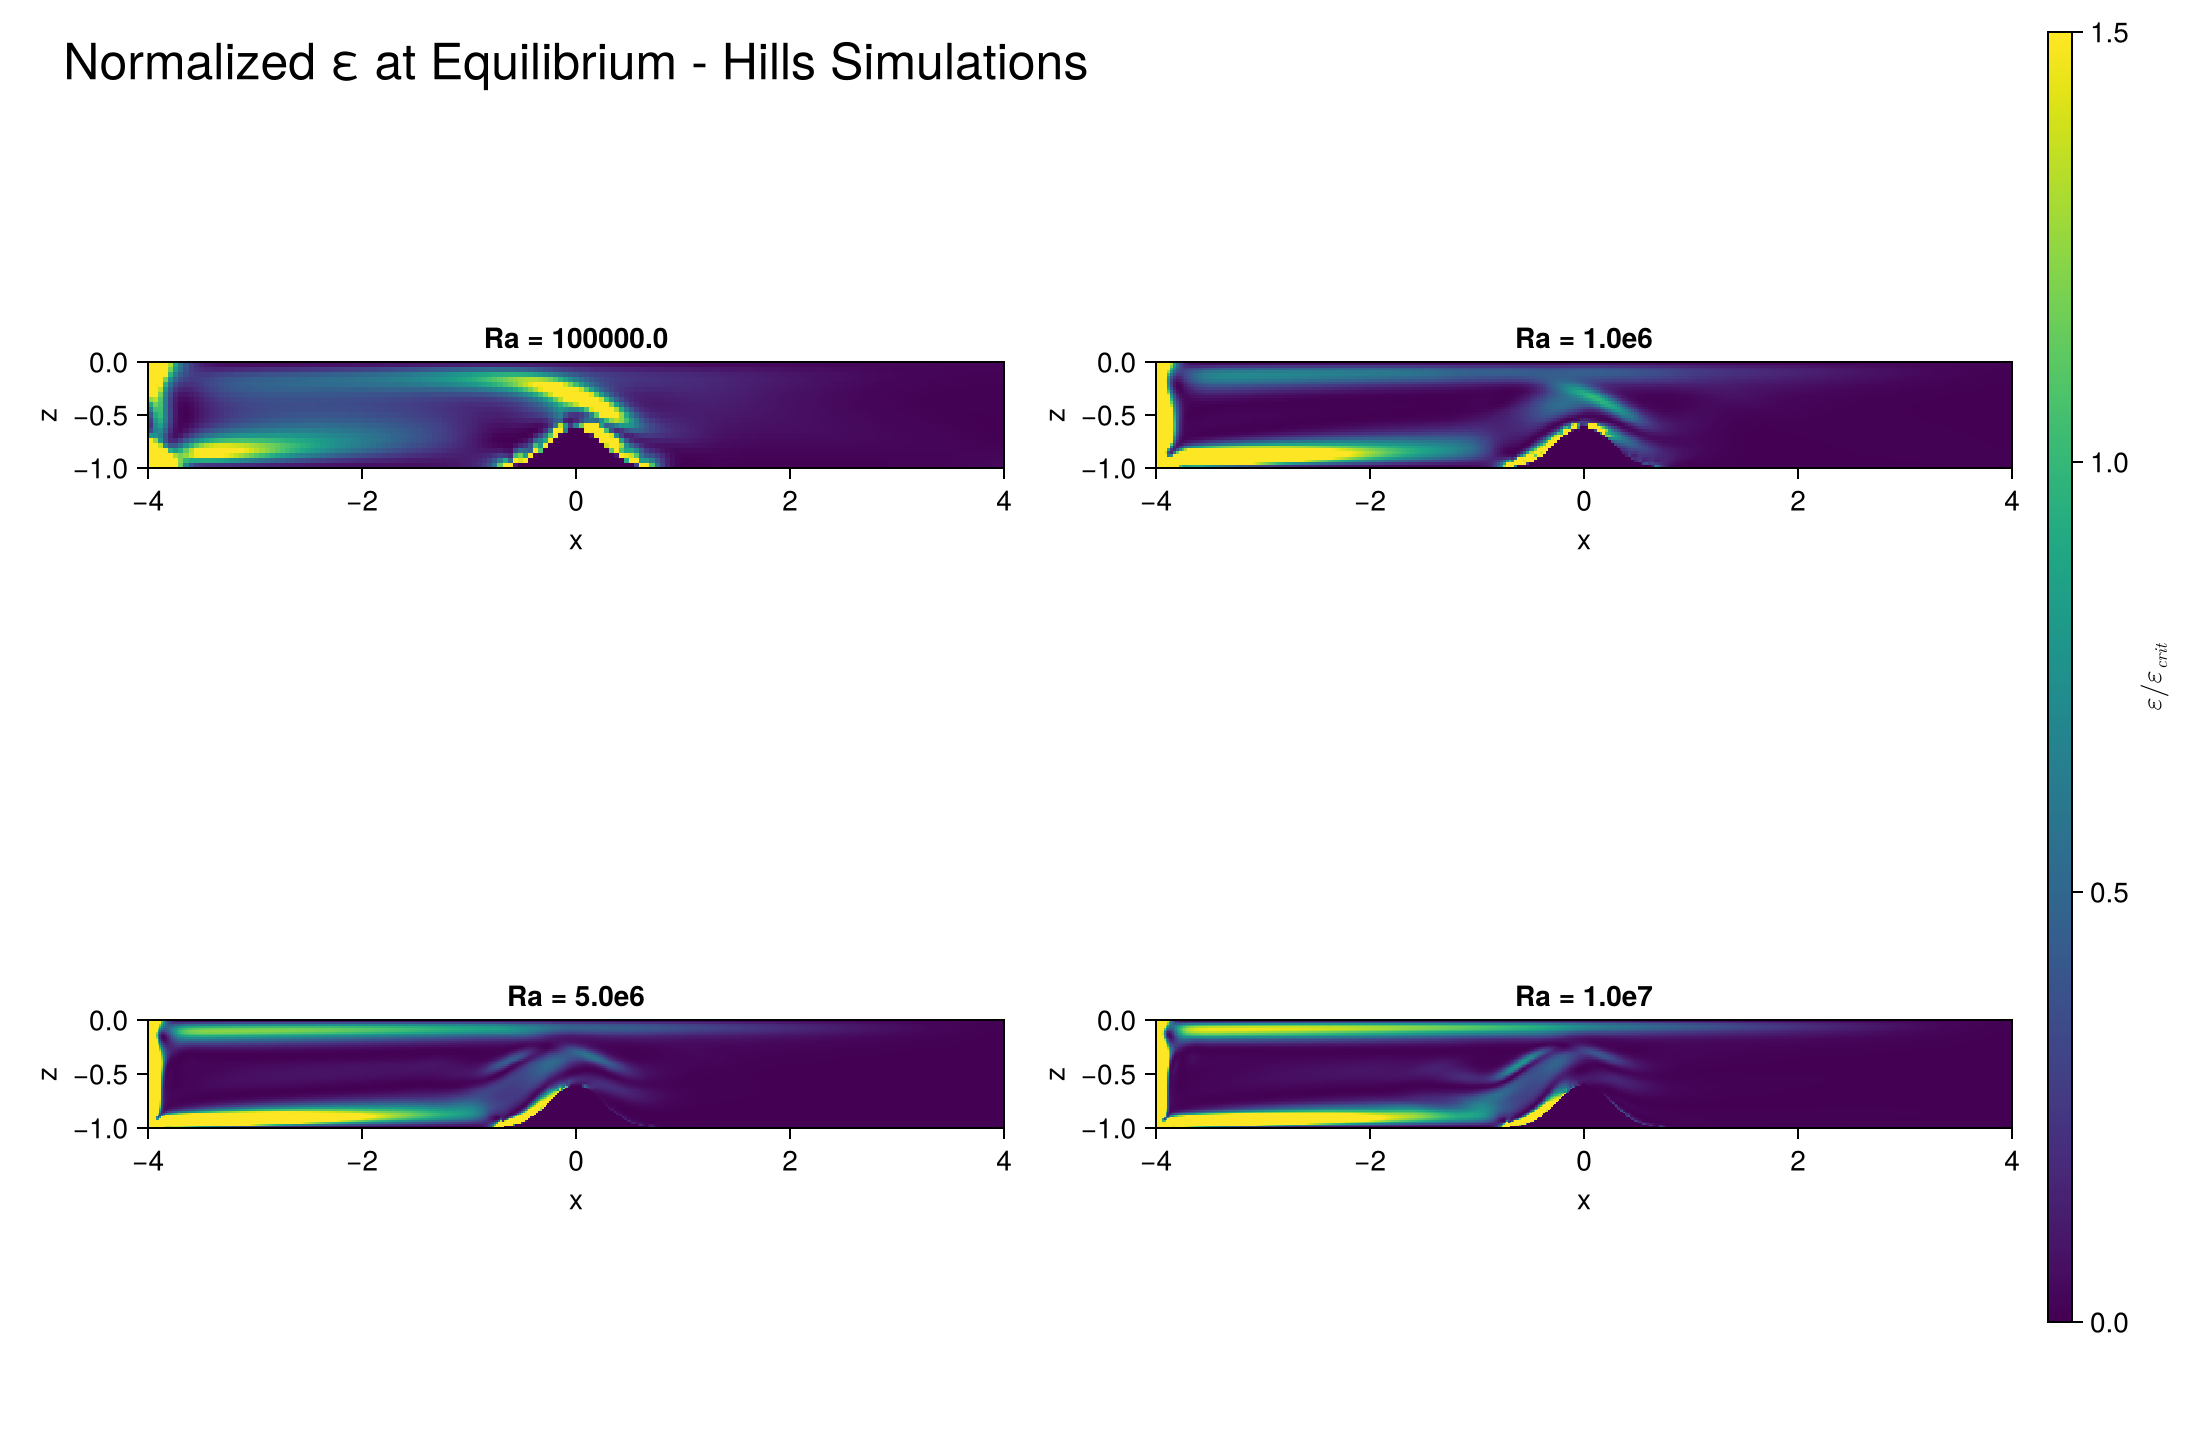

In [122]:
fig_hills = ε_norm_eq_subplots(list_hill_datasets, (0,1.5), cols=2, 
        main_title="Normalized ε at Equilibrium - Hills Simulations")
fig_hills

Simulations for advancement! 

Part 1) Simulations of Cold Started Horizontal Convection (no hills) with increasing Rayleigh number. 

In [8]:
using Oceananigans

In [3]:
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [1]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

No hills simulations of horizontal convection:: Ra = 1e5 to 1e7. 

Below is an animation of Ra=1e5 -- laminar

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e5.mp4" type "video/mp4">
</video>

In [2]:
using TopographicHorizontalConvection:ε_analysis
using TopographicHorizontalConvection:plot_ε_normalized
using TopographicHorizontalConvection:plot_ε_avg

we want to create a heatmap comparing simulation epsilon to theoretical epsilon at the equilibrium time. let's assume the equilibrium time is the last ten percent of the timeseries. 

In [9]:
ε_0 = ds0_o["ε"][4+1:end-4, :, 4+1:end-4, :];
time_0 = ds0_o["time"][:];
x = ds0_o["xC"][4+1:end-4];
z = ds0_o["zC"][4+1:end-4];

function plot_ε_equilibrium(ds)
    ε = ds["ε"][4+1:end-4, :, 4+1:end-4, :]
    Ra = ds.attrib["Ra"]
    time = ds["time"][:]
    x = ds["xC"][4+1:end-4]
    z = ds["zC"][4+1:end-4]
    equilibrium_start = round(Int, 0.7 * size(time, 1))
    time_eq_start = time[equilibrium_start]
    ε_eq = ε[:, 1, :, equilibrium_start]

    ε_theory = ε_analysis(ds)[1]

    fig = Figure()
    ax = Axis(fig[1, 1], aspect =8, xlabel="x", ylabel="z", title="Mechanical Energy Dissipation Rate Normalized of Ra = $Ra Simulation at Equilibrium Time")

    hm = heatmap!(ax, x, z, ε_eq, colormap=:viridis)
    Colorbar(fig[1, 2], hm)
    return fig
end


plot_ε_equilibrium (generic function with 1 method)

Next is the Ra=1e6 no hills simulation

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e6.mp4" type "video/mp4">
</video>

In the second simulation we increase the Rayleigh number to 1e7
I didn't run this all the way to equilibrium $\tau_{eq} = \sqrt{1\times 10^{8}}$ because it took over 12 hours to just run up to $t=1830$ locally. 

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e7.mp4" type "video/mp4">
</video>

In [93]:
#equilibrium ε plot
function ε_norm_eq_plot(ds, CR)
    ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
    Ra = ds.attrib["Ra"]
    time = ds["time"][:]
    #print(size(time))
    x = ds["xC"][4+1:end-4]
    z = ds["zC"][4+1:end-4]
    equilibrium_start = round(Int, 0.9 * size(time, 1))
    time_eq_start = time[equilibrium_start]
    ε_eq = ε[:, :, equilibrium_start]
    ε_theory = ε_analysis(ds)[1]
    ε_norm = ε_eq ./ ε_theory

    fig = Figure(size=(800, 400))
    ax = Axis(fig[1, 1], aspect =8, 
            xlabel="x", ylabel="z", 
            title = "Normalized ε of Ra = $Ra Simulation at Equilibrium Time")
    hm = heatmap!(ax, x, z, ε_norm, colorrange = CR ,colormap=:viridis)
    Colorbar(fig[1, 2], hm, label=L"ε/ε_{crit}")

    return fig
end


ε_norm_eq_plot (generic function with 1 method)

Below is the animation and similar analysis plot for Ra=5e6

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills5e6.mp4" type "video/mp4">
</video>

NOW for the hills simulations

we start with Ra=1e5

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e5.mp4" type "video/mp4">
</video>

below is Ra=1e6 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e6.mp4" type "video/mp4">
</video>

Rayleigh number 1e7 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e7.mp4" type "video/mp4">
</video>

okay, time to make a joint plot of normalized epsilon vs time for all RA

lets start with no hills

In [61]:
#import the data here so I dont have to run all the turbulent_convection_hills_section_snapshots

ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/oceanostics.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/oceanostics.nc"));

list_of_datasets = [ds0_o, ds1_o, ds2_o, ds3_o]


#hills

ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

list_hill_datasets = [ds_h0_o, ds_h1_o, ds_h2_o, ds_h3_o];

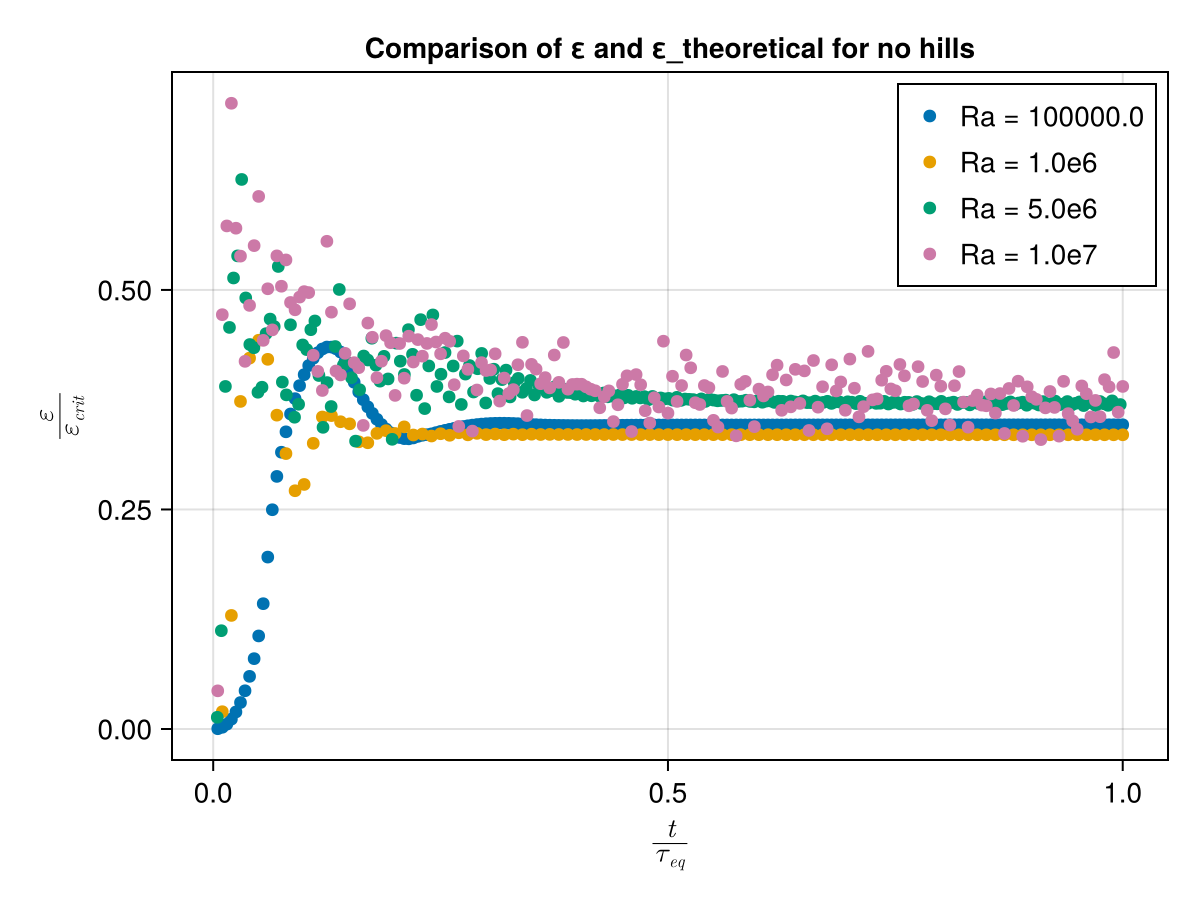

In [62]:
f = Figure()
ax = Axis(f[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{crit}}", title="Comparison of ε and ε_theoretical for no hills")
for ds in list_of_datasets
    plot_ε_normalized(ax, ds)
end

axislegend(ax)
f

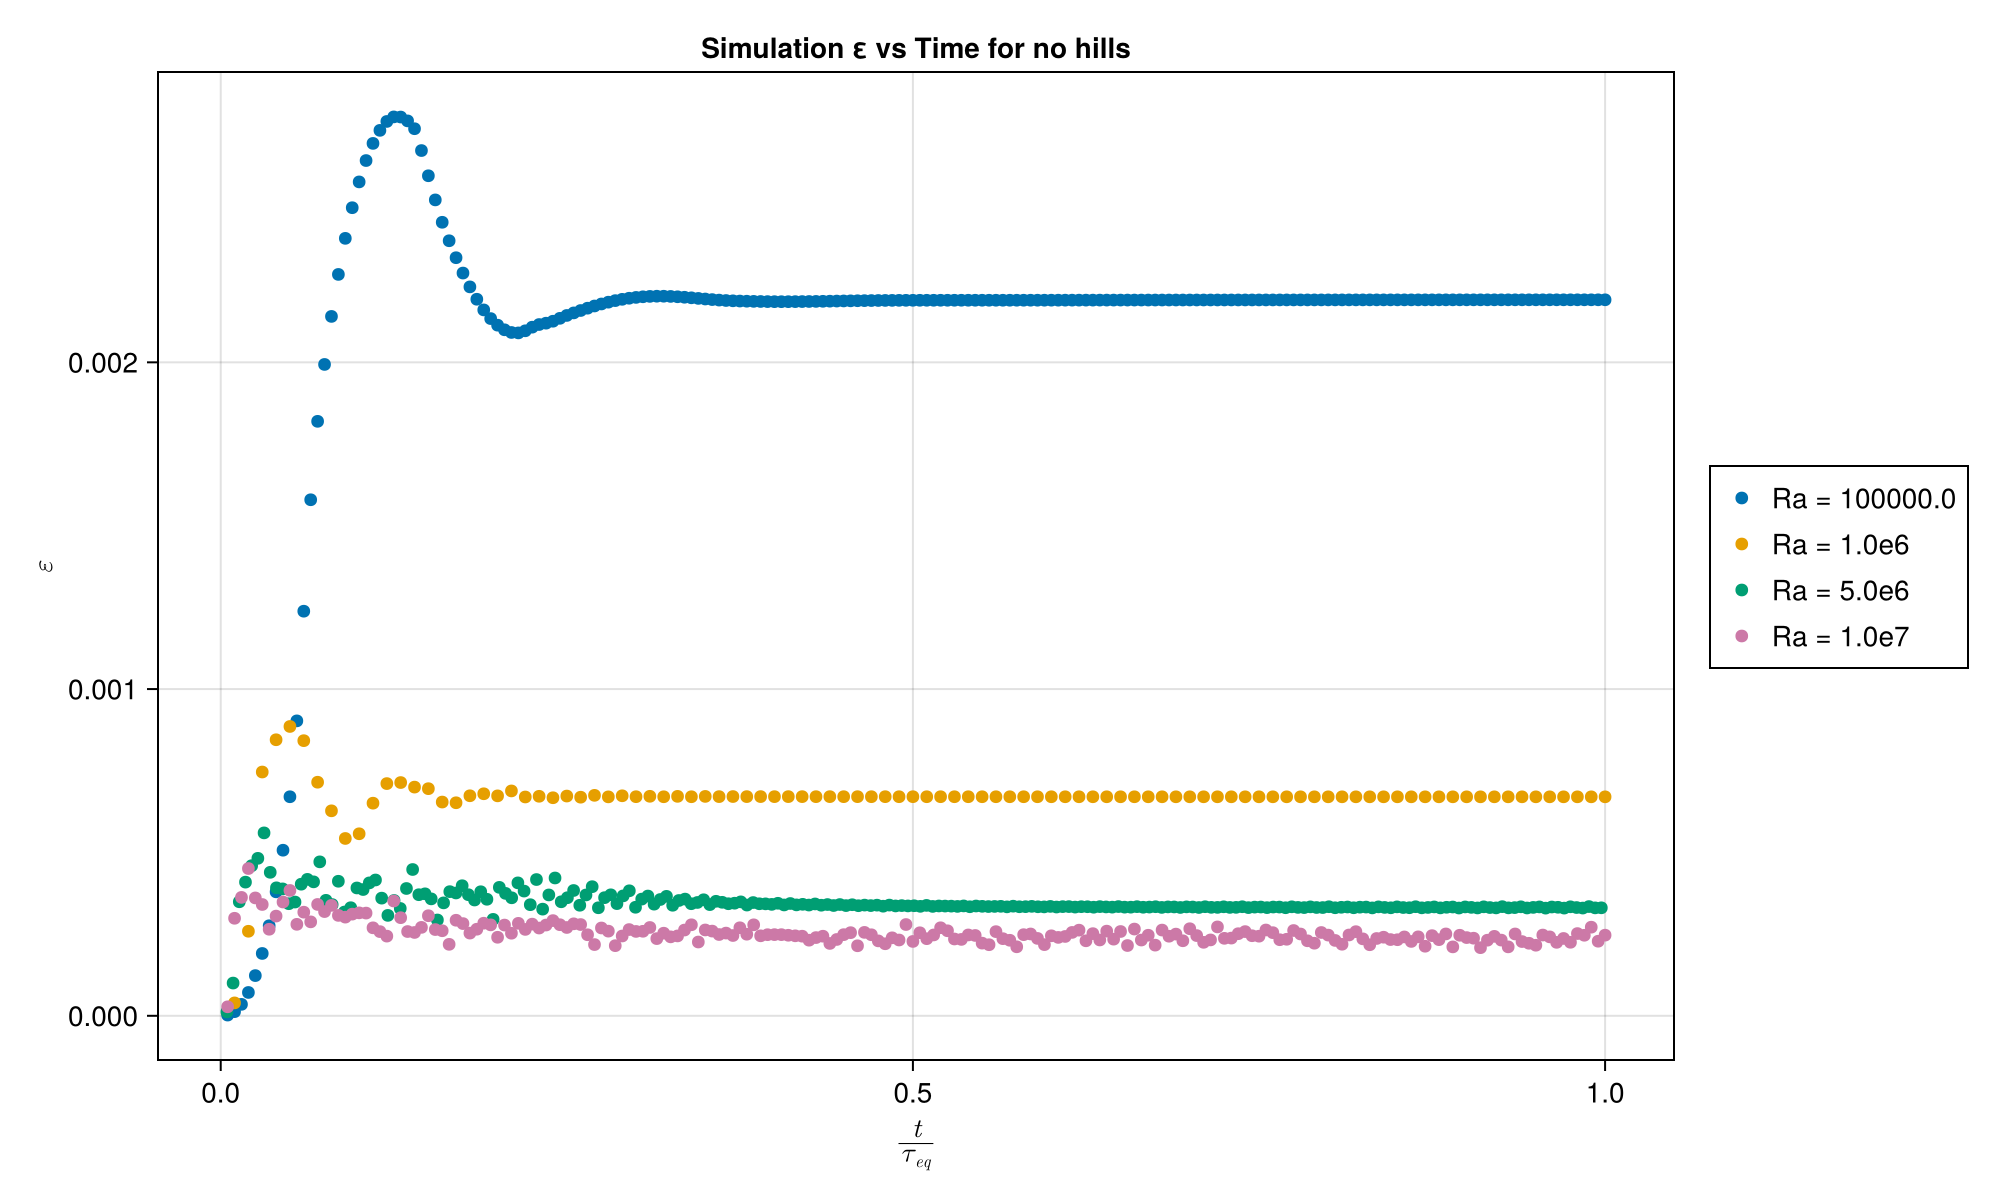

In [63]:
f1 = Figure(size=(1000, 600))
ax1 = Axis(f1[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Simulation ε vs Time for no hills")
for ds in list_of_datasets
    plot_ε_avg(ax1, ds)
end
Legend(f1[1, 2], ax1)  # Place legend in separate column
f1

Next, we want to make a scatter plot for the mean $\varepsilon$ averaged over the equilibrium period versus the Rayleigh number.

We also want to add theoretical $\varepsilon$ prediction curve to this plot. 

Recall : $\varepsilon_{crit} = 2 \kappa b_{\bigstar} H^{-1} $

We want $\varepsilon_{crit} $ as a function of the Rayleigh number, $Ra$. and Rayleigh number: $Ra = \frac{b_{\bigstar} H^3}{\nu \kappa}$

therefore, $\kappa = \frac{b_{\bigstar}H^3}{\nu Ra} $ and $\nu = \sqrt{\frac{Pr b_{\bigstar} H^3 } {Ra}}$ and $Pr = \frac{\nu}{\kappa}$ where Pr = 1

$b_{\bigstar} = H = 1 $ and $Pr = 1 $ , therefore $\nu = \kappa = \frac{1}{\sqrt{Ra}} $

and $\varepsilon_{crit} = \frac{2}{\sqrt{Ra}} $

we need to nondimensionalize the $\varepsilon$ scatter plot, since Ra is a nondimensional number. so we divide mean and critical $\varepsilon$ by $\frac{\kappa^3}{H^4}

this makes $\varepsilon_{crit} = 2 Ra $ 

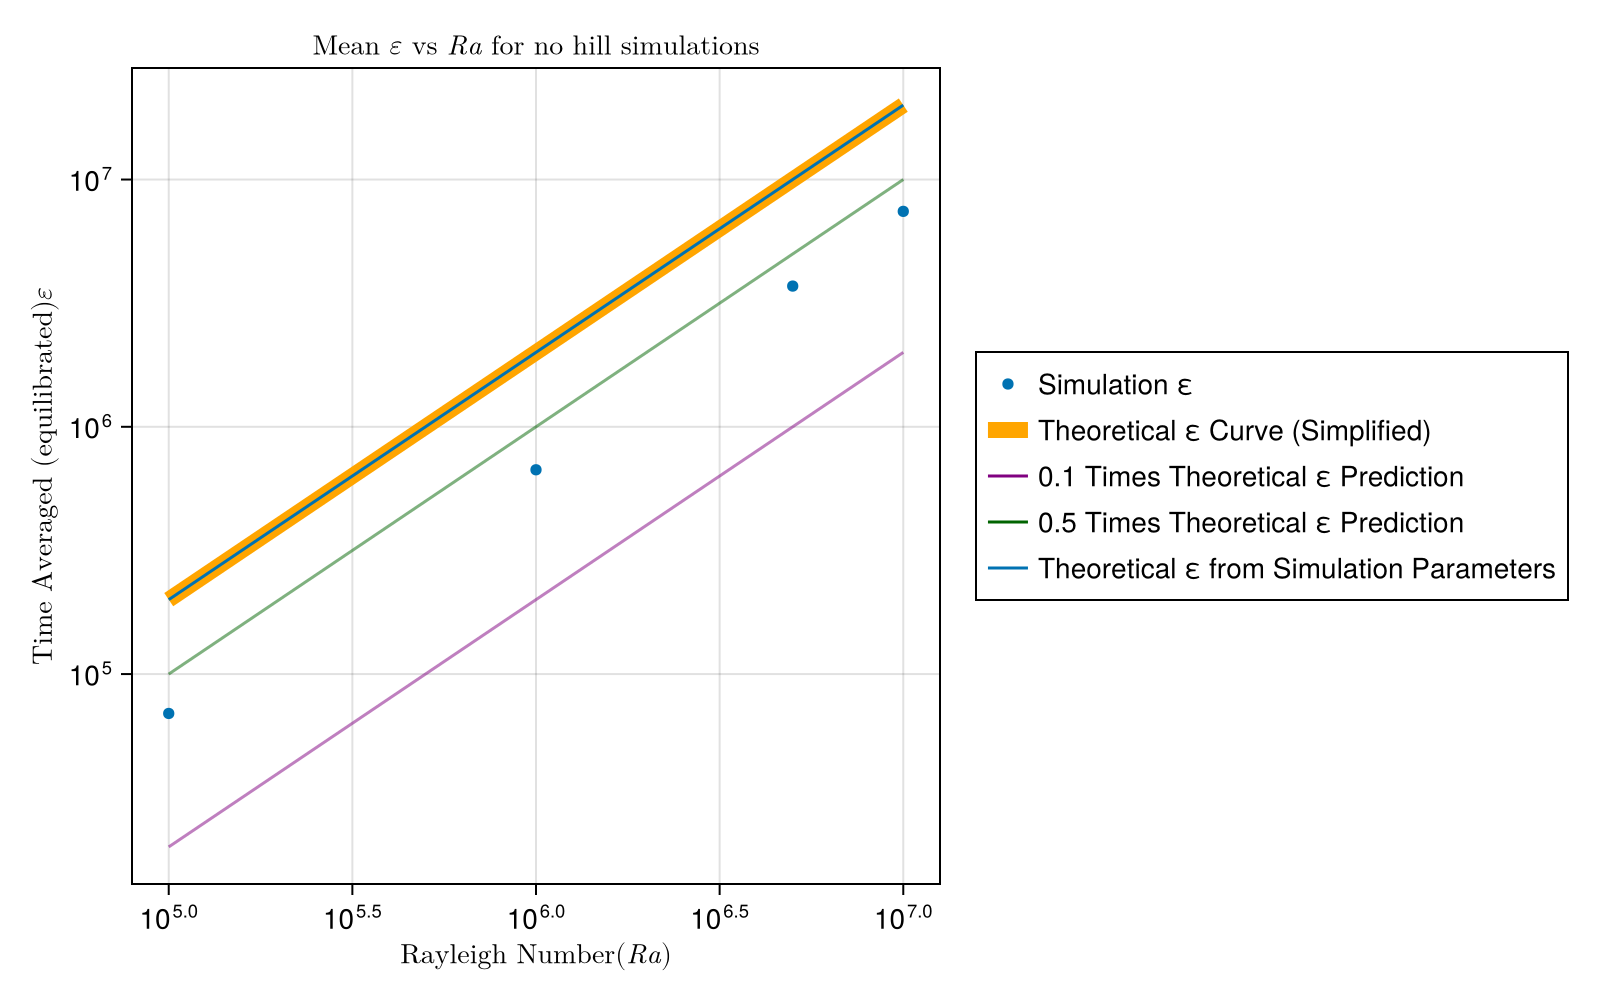

In [65]:
f_ε_scatter = Figure(size = (800, 500))
ax_ε_scatter = Axis(f_ε_scatter[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated)} \varepsilon", 
    title=L"\text{Mean } \varepsilon \text{ vs } Ra \text{ for no hill simulations}")

Ra_vals = Float64[]
ε_means = Float64[]
ε_theories_from_sim = Float64[]
ε_theories_from_brain = Float64[]

for ds in list_of_datasets
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    ε_mean = ε_analysis(ds)[3] ./ (ν^3 / H^4) # nondimensionalize ε_mean
    ε_sim_theory = ε_analysis(ds)[1] ./ (ν^3 / H^4) # nondimensionalize ε_sim_theory

    push!(Ra_vals, Ra)
    push!(ε_means, ε_mean)
    push!(ε_theories_from_brain, 2 *(Ra))
    push!(ε_theories_from_sim, ε_sim_theory)
end


#plot the scatter points
scatter!(ax_ε_scatter, Ra_vals, ε_means, label="Simulation ε", markersize=8)
#theoretical prediction curve
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain, label="Theoretical ε Curve (Simplified)", linewidth=8, color=:orange)
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain .* 0.1, label="0.1 Times Theoretical ε Prediction", alpha=0.5, color=:purple)
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain .* 0.5, label="0.5 Times Theoretical ε Prediction", alpha=0.5, color=:darkgreen)
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_sim, label = "Theoretical ε from Simulation Parameters")

Legend(f_ε_scatter[1, 2], ax_ε_scatter)
f_ε_scatter



okay, so the pink theoretical $\varepsilon$ curve comes from the algebraic manipulation of the definitions, plugging in the simulation parameters that remain constant ($H, b_{\bigstar}, \text{and } Pr$), and solving as a function of rayleigh number. This gave us $\varepsilon = \frac{2}{\sqrt{Ra}}$

the blue theoretical $\varepsilon$ curve comes from the plugging in the global attributes of the simulation directly into the theoretical definition of $\varepsilon = 2 \kappa b_{\bigstar} H^{-1} $

It's clear from the figure above that something went wrong with the $Ra = 1e5$ and $Ra = 5e6$ simulations. 

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill5e6.mp4" type "video/mp4">
</video>

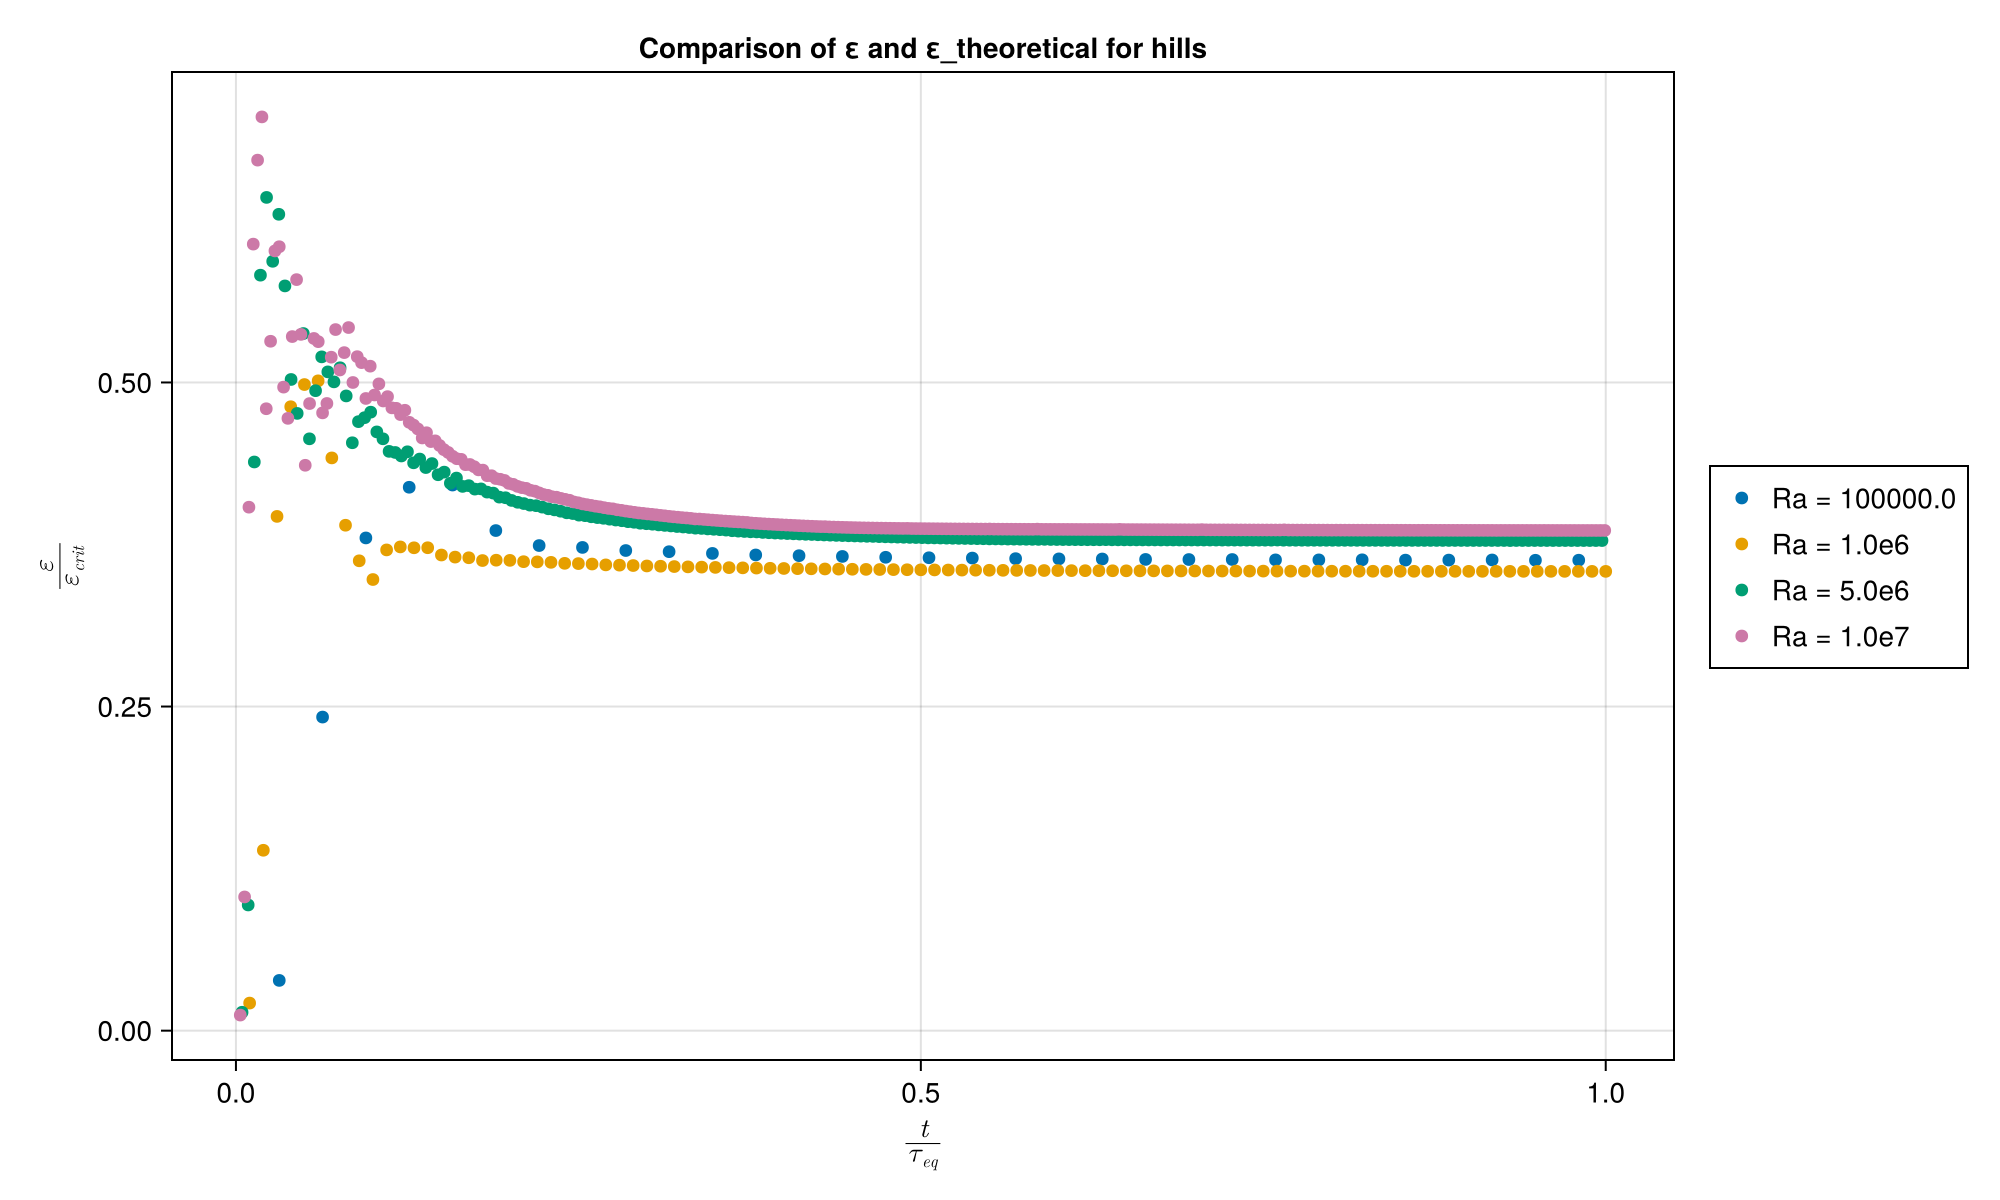

In [ ]:
f_hills = Figure(size=(1000, 600))
ax_hills = Axis(f_hills[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{crit}}", title="Comparison of ε and ε_theoretical for hills")
for ds in list_hill_datasets
    plot_ε_normalized(ax_hills, ds)
end

Legend(f_hills[1, 2], ax_hills)
f_hills

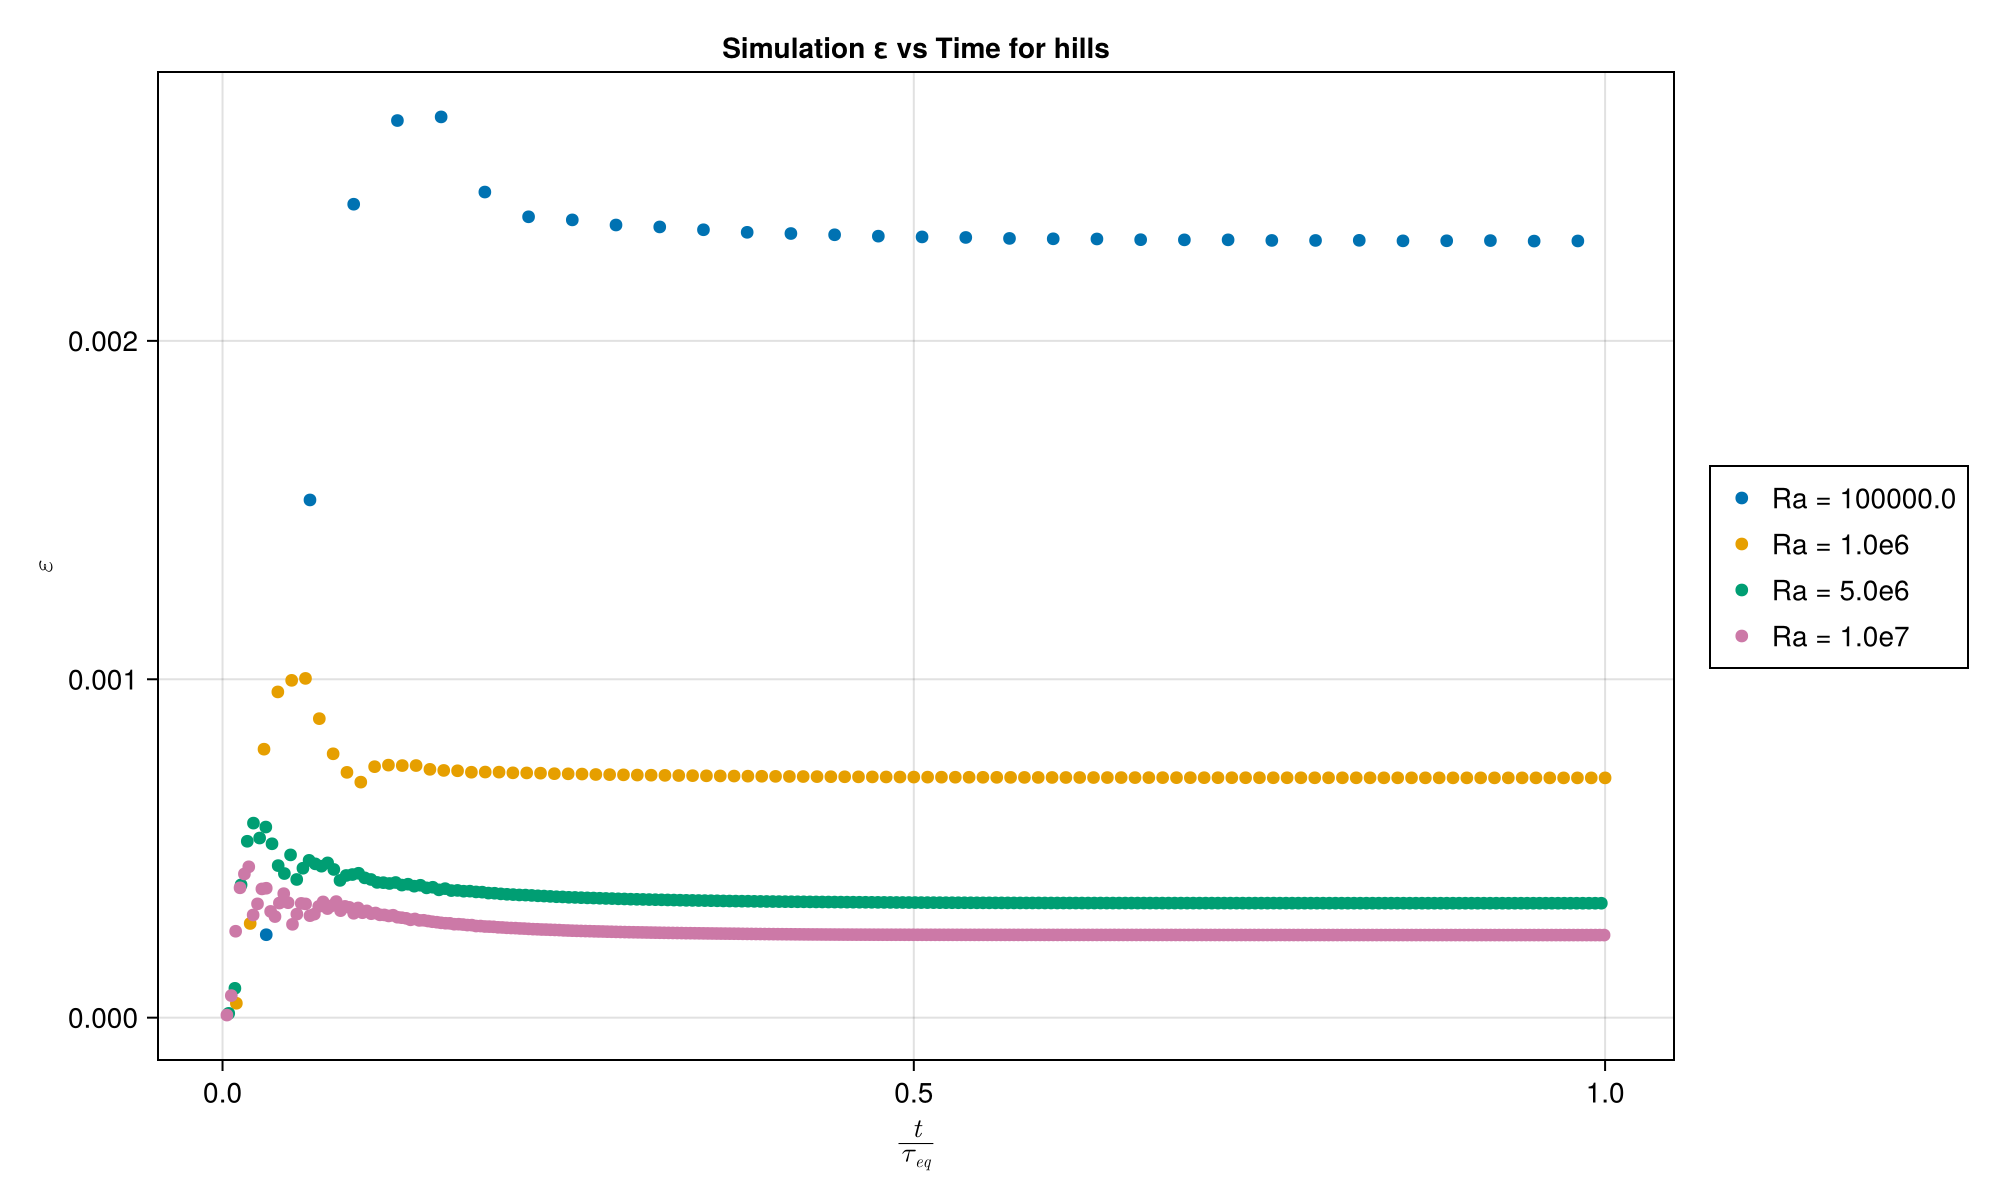

In [67]:
f_hills_2 = Figure(size=(1000, 600))
ax_hills_2 = Axis(f_hills_2[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Simulation ε vs Time for hills")
for ds in list_hill_datasets
    plot_ε_avg(ax_hills_2, ds)
end
Legend(f_hills_2[1, 2], ax_hills_2)
f_hills_2

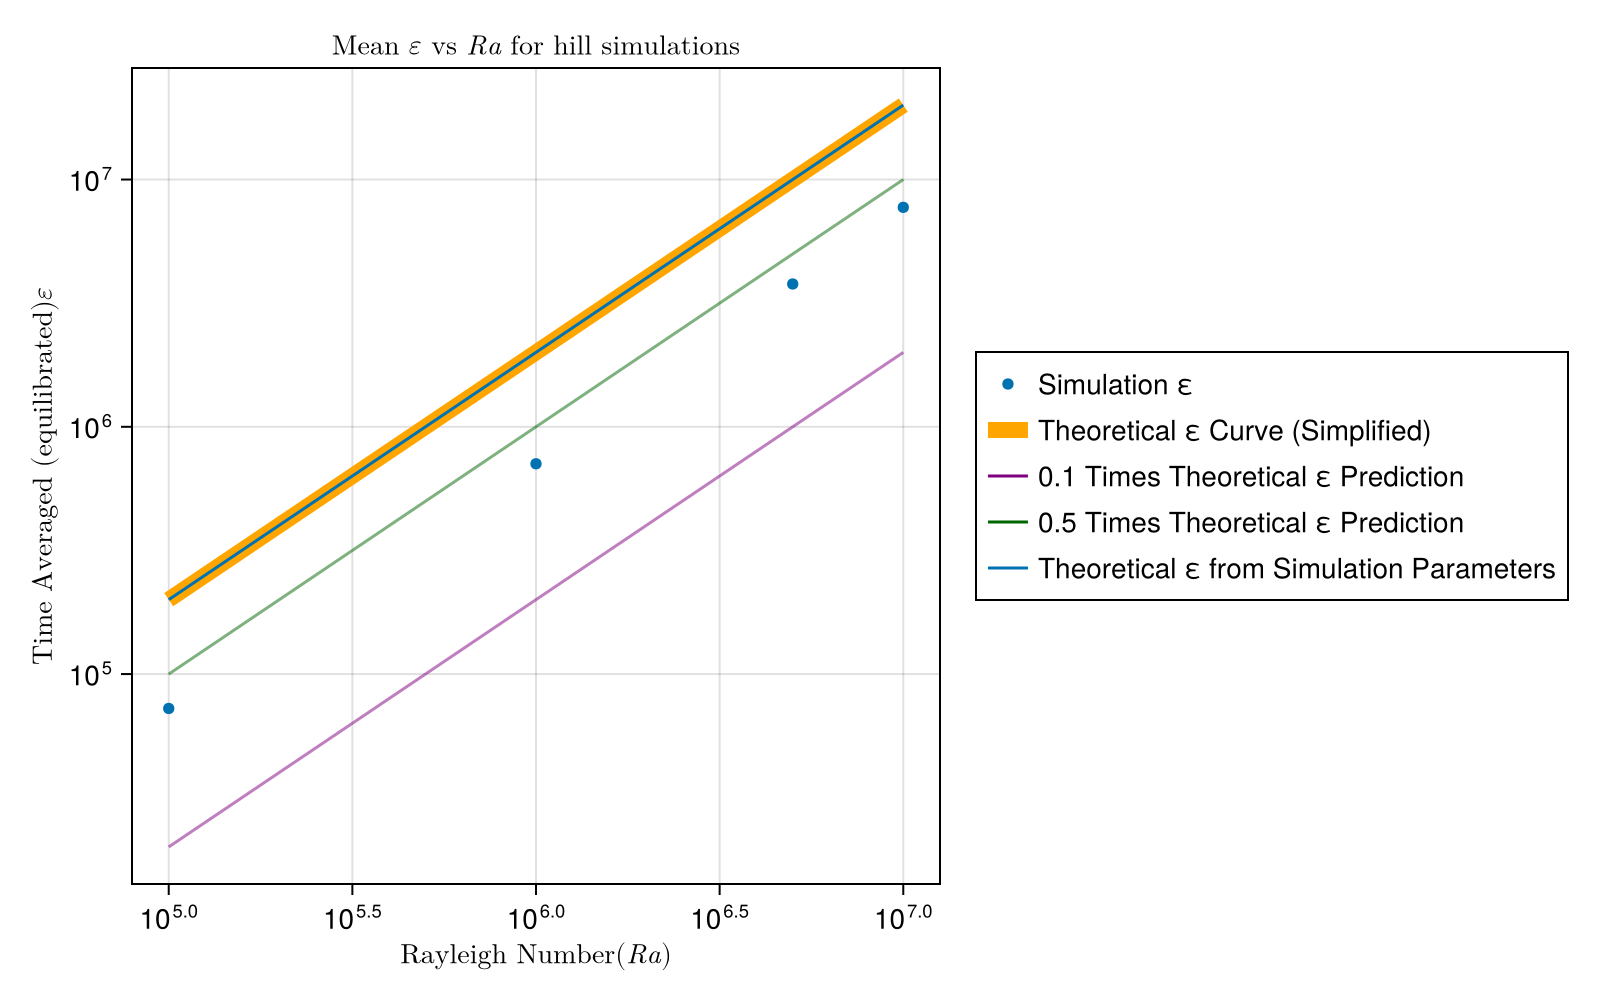

In [ ]:
f_ε_scatter_hill = Figure(size = (800, 500))
ax_ε_scatter_hill = Axis(f_ε_scatter_hill[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated)} \varepsilon", 
    title=L"\text{Mean } \varepsilon \text{ vs } Ra \text{ for hill simulations}")

Ra_vals = Float64[]
ε_means_hill = Float64[]
ε_theories_from_sim_hill = Float64[]
ε_theories_from_brain_hill = Float64[]

for ds in list_hill_datasets
    Ra = ds.attrib["Ra"]
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    ε_mean = ε_analysis(ds)[3] ./ (ν^3 / H^4) # nondimensionalize ε_mean
    ε_sim_theory = ε_analysis(ds)[1] ./ (ν^3 / H^4) # nondimensionalize ε_sim_theory
    

    push!(Ra_vals, Ra)
    push!(ε_means_hill, ε_mean)
    push!(ε_theories_from_brain_hill, 2 *(Ra))
    push!(ε_theories_from_sim_hill, ε_sim_theory)
end


#plot the scatter points
scatter!(ax_ε_scatter_hill, Ra_vals, ε_means_hill, label="Simulation ε", markersize=8)
#theoretical prediction curve
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill, label="Theoretical ε Curve (Simplified)", linewidth=8, color=:orange)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill .* 0.1, label="0.1 Times Theoretical ε Prediction", alpha=0.5, color=:purple)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill .* 0.5, label="0.5 Times Theoretical ε Prediction", alpha=0.5, color=:darkgreen)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_sim_hill, label = "Theoretical ε from Simulation Parameters")

Legend(f_ε_scatter_hill[1, 2], ax_ε_scatter_hill)
f_ε_scatter_hill

